In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
ezs = np.load('ladder_ansatz_data.npy')

In [10]:
np.shape(ezs)

(2, 3, 180)

In [ ]:
theta=np.linspace(0,2*np.pi,180)


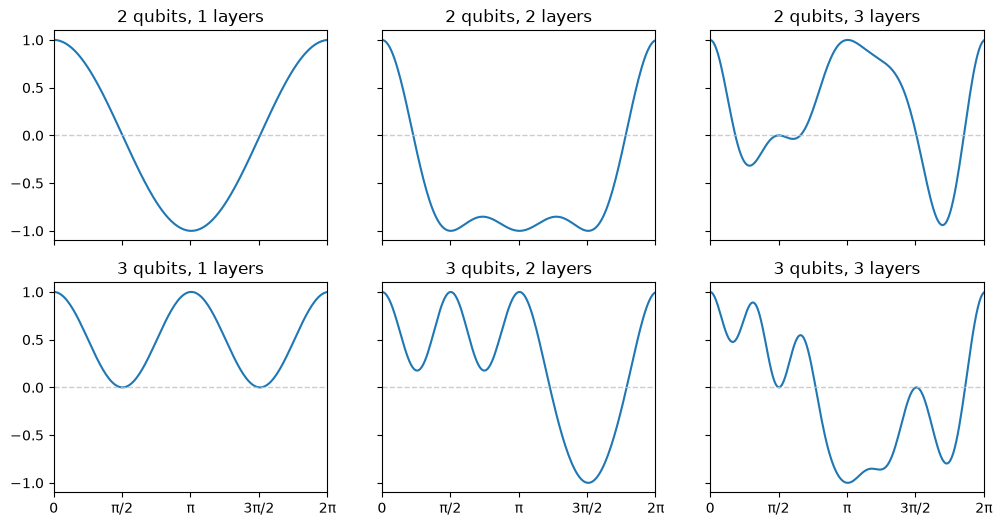

In [28]:
fig, axes = plt.subplots(2, 3,figsize=(12, 6), sharex=True, sharey=True)

ticks  = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
labels = ['0', 'π/2', 'π', '3π/2', '2π']

for i in range(2):
    for j in range(3):
        axes[i][j].plot(theta,ezs[i][j])
        axes[i][j].set_title(f'{n_qubits[i]} qubits, {n_layers[j]} layers')
        axes[i][j].axhline(0, color='silver', ls='--', alpha=0.8, lw=1)


axes[0][0].set_xlim(0, 2*np.pi)     
axes[0][0].set_ylim(-1.1, 1.1)
axes[0][0].set_xticks(ticks)
axes[0][0].set_xticklabels(labels)

plt.show()

In [31]:
dx = theta[1] - theta[0]

def d(v):
    return (np.roll(v,-1) - np.roll(v,1)) / (2*dx)

def zero_cross(v):
    s = np.sign(v); s[s==0] = 1
    return np.where(s != np.roll(s,1))[0]

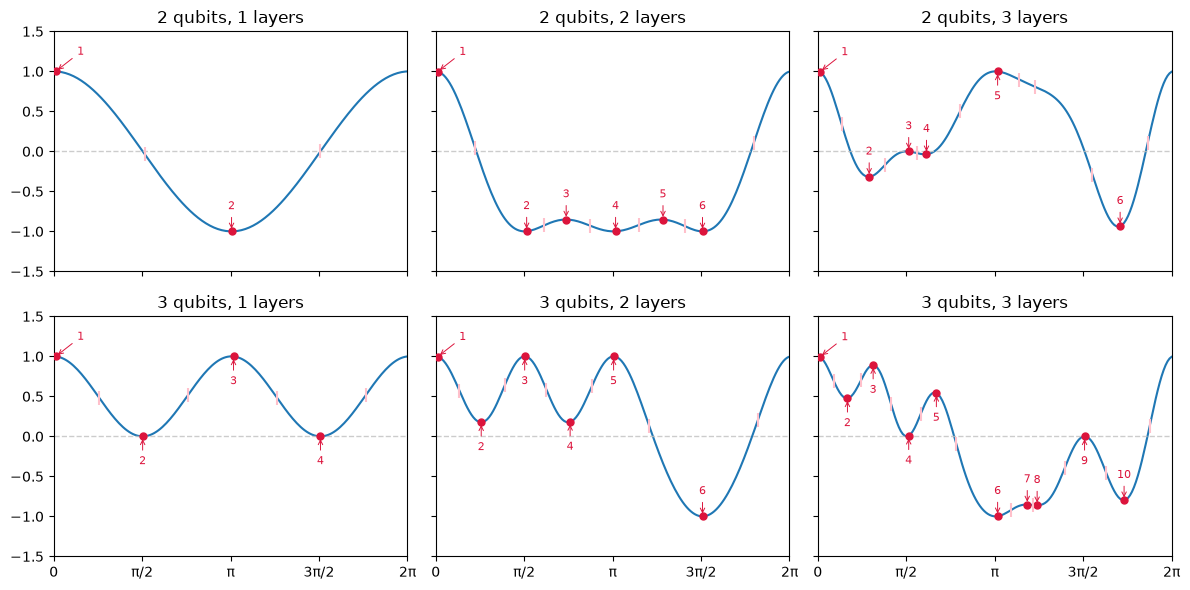

In [ ]:
fig, axes = plt.subplots(2, 3,figsize=(12, 6), sharex=True, sharey=True)

ticks  = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
labels = ['0', 'π/2', 'π', '3π/2', '2π']



for i in range(2):
    for j in range(3):
        axes[i][j].plot(theta, ezs[i][j])
        axes[i][j].set_title(f'{n_qubits[i]} qubits, {n_layers[j]} layers')
        axes[i][j].axhline(0, color='silver', ls='--', alpha=0.8, lw=1)

        # ↓ 여기부터 추가
        ax = axes[i][j]
        y  = ezs[i][j]
        d1 = d(y)
        d2 = d(d1)

        ext = zero_cross(d1)
        infl = zero_cross(d2)

        ax.plot(theta[ext],  y[ext],  'o', ms=5, color='crimson',  zorder=3)
        ax.plot(theta[infl], y[infl], '|', ms=10,mew=1.5, color='pink', zorder=3)

        n = len(theta)
        for k, m in enumerate(ext):
            if m == ext[0]:   off = (18, 12)     
            elif y[m] < 0:    off = (0, 16)
            else:             off = (0, -20)
            ax.annotate(f'{k+1}', xy=(theta[m], y[m]), xytext=off,
                        textcoords='offset points', ha='center',
                        fontsize=8, color='crimson',
                        arrowprops=dict(arrowstyle='->', lw=0.7, color='crimson'))
                

axes[0][0].set_xlim(0, 2*np.pi)     
axes[0][0].set_ylim(-1.5, 1.5)
axes[0][0].set_xticks(ticks)
axes[0][0].set_xticklabels(labels)
axes[0][0].set_xlabel(r'frequency $\omega$')
axes[0][0].set_ylabel(r'frequency $\omega$')
fig.tight_layout()
plt.show()